In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from link_prediction.complexity_analysis import (
    run_complexity_analysis,
)
from link_prediction.config import (
    RESULTS_DIR,
)
from link_prediction.runtime_analysis import (
    run_runtime_analysis,
)
from link_prediction.statistical_analysis import (
    load_benchmark_fold_metrics,
)

In [2]:
benchmark_name = "standard"

figure_directory = (
    RESULTS_DIR
    / "figures"
    / benchmark_name
)

figure_directory.mkdir(
    parents=True,
    exist_ok=True,
)

fold_metrics = (
    load_benchmark_fold_metrics(
        benchmark_name=
            benchmark_name,
    )
)

runtime_results = run_runtime_analysis(
    fold_metrics=
        fold_metrics,
    benchmark_name=
        benchmark_name,
)

complexity_table = (
    run_complexity_analysis()
)

family_folds = runtime_results[
    "family_folds"
]

network_runtime = runtime_results[
    "network_runtime"
]

family_runtime = runtime_results[
    "family_runtime"
]

In [3]:
family_runtime[
    [
        "family",
        "analysis_family",
        "network_count",
        "method_count",
        "mean_candidate_count",
        "mean_scoring_seconds",
        "median_scoring_seconds",
        "mean_candidates_per_second",
    ]
].sort_values(
    [
        "mean_scoring_seconds",
        "family",
    ]
).reset_index(
    drop=True
)

,family,analysis_family,network_count,method_count,mean_candidate_count,mean_scoring_seconds,median_scoring_seconds,mean_candidates_per_second
0,degree_based,standard_local,8,1,12627.1,0.027351,0.010730,343642.541390
1,local_similarity,standard_local,8,9,12627.1,0.338048,0.082328,51736.509470
2,local_bayesian,local_bayesian,8,3,12627.1,0.581157,0.160476,30356.644563
3,quasi_local_path,quasi_local_path,8,3,12627.1,29.362258,0.587535,10128.055510
4,quasi_local_walk,quasi_local_walk,8,3,12627.1,32.250476,2.203108,4034.271311
5,enhanced_local,enhanced_local,8,8,12627.1,33.228622,1.461602,3313.429631


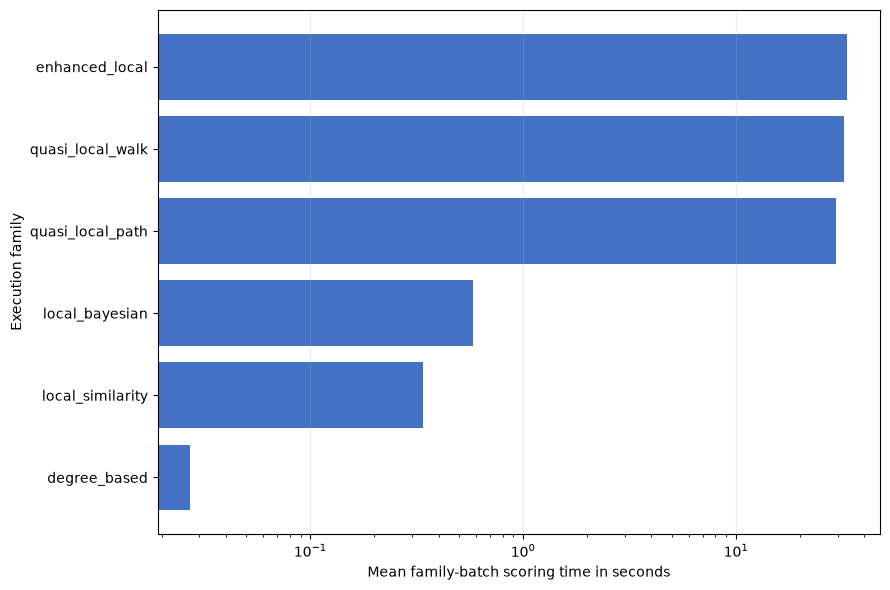

In [4]:
runtime_plot = (
    family_runtime
    .sort_values(
        [
            "mean_scoring_seconds",
            "family",
        ]
    )
)

figure, axis = plt.subplots(
    figsize=(
        9,
        6,
    )
)

axis.barh(
    runtime_plot[
        "family"
    ],
    runtime_plot[
        "mean_scoring_seconds"
    ],
    color="#4472C4",
)

axis.set_xscale(
    "log"
)

axis.set_xlabel(
    "Mean family-batch scoring time in seconds"
)

axis.set_ylabel(
    "Execution family"
)

axis.grid(
    axis="x",
    alpha=0.25,
)

figure.tight_layout()

figure.savefig(
    figure_directory
    / "family_runtime.png",
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_directory
    / "family_runtime.pdf",
    bbox_inches="tight",
)

plt.show()

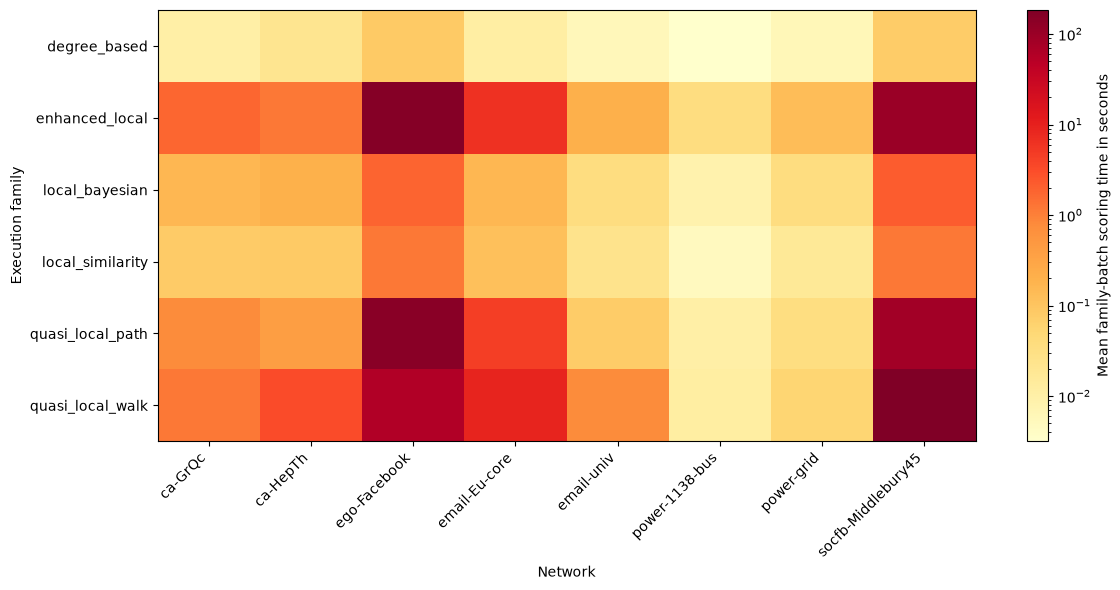

In [5]:
runtime_matrix = (
    network_runtime
    .pivot(
        index="family",
        columns="network",
        values="mean_scoring_seconds",
    )
    .sort_index()
)

figure, axis = plt.subplots(
    figsize=(
        12,
        6,
    )
)

image = axis.imshow(
    runtime_matrix.to_numpy(),
    aspect="auto",
    cmap="YlOrRd",
    norm=LogNorm(
        vmin=float(
            runtime_matrix.min().min()
        ),
        vmax=float(
            runtime_matrix.max().max()
        ),
    ),
)

axis.set_xticks(
    range(
        len(
            runtime_matrix.columns
        )
    )
)

axis.set_xticklabels(
    runtime_matrix.columns,
    rotation=45,
    ha="right",
)

axis.set_yticks(
    range(
        len(
            runtime_matrix.index
        )
    )
)

axis.set_yticklabels(
    runtime_matrix.index,
)

axis.set_xlabel(
    "Network"
)

axis.set_ylabel(
    "Execution family"
)

colorbar = figure.colorbar(
    image,
    ax=axis,
)

colorbar.set_label(
    "Mean family-batch scoring time in seconds"
)

figure.tight_layout()

figure.savefig(
    figure_directory
    / "network_family_runtime_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

figure.savefig(
    figure_directory
    / "network_family_runtime_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

In [6]:
complexity_table[
    [
        "method",
        "family",
        "analysis_family",
        "complexity",
        "complexity_latex",
    ]
].sort_values(
    [
        "analysis_family",
        "family",
        "method",
    ]
).reset_index(
    drop=True
)

,method,family,analysis_family,complexity,complexity_latex
0,CAR-AA,enhanced_local,enhanced_local,O(v k^4),$O(vk^4)$
1,CAR-CN,enhanced_local,enhanced_local,O(v k^4),$O(vk^4)$
2,CAR-RA,enhanced_local,enhanced_local,O(v k^4),$O(vk^4)$
3,FSW,enhanced_local,enhanced_local,O(v k^3),$O(vk^3)$
4,IA1,enhanced_local,enhanced_local,O(v k^4),$O(vk^4)$
5,IA2,enhanced_local,enhanced_local,O(v k^3),$O(vk^3)$
6,LIT-i2,enhanced_local,enhanced_local,O(l v k^3),$O(lvk^3)$
7,RA-CNI,enhanced_local,enhanced_local,O(v k^4),$O(vk^4)$
8,LNB-AA,local_bayesian,local_bayesian,O(v k^3),$O(vk^3)$
9,LNB-CN,local_bayesian,local_bayesian,O(v k^3),$O(vk^3)$
